# Customer Journey Path Optimization — Experiment Analysis

This notebook analyses results from the full experiment matrix:
- **Graph types**: Erdős–Rényi, Layered (funnel)
- **Sizes**: |V| ∈ {1,000, 5,000, 10,000}
- **Degrees**: d̄ ∈ {2, 5, 10}
- **Distributions**: uniform, power-law
- **Algorithms**: Baseline Dijkstra vs Probability-Pruned Dijkstra
- **τ values**: {0, 0.001, 0.01, 0.05, 0.1, 0.5}
- **10 runs** per configuration

### Plots
1. Speedup vs τ curves
2. Optimality gap vs τ
3. Scalability (execution time vs |V|, log-log)
4. Critical τ heatmap
5. Memory scaling (baseline vs pruned)
6. Statistical significance testing (Wilcoxon signed-rank)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

IMG_DIR = Path("results/img")
IMG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("results/experiment_results.csv")

# Separate baseline (tau=0) and pruned (tau>0)
baseline = df[df["algorithm"] == "baseline"].copy()
pruned = df[df["algorithm"] == "pruned"].copy()

print(f"Total rows: {len(df)}")
print(f"Baseline rows: {len(baseline)}, Pruned rows: {len(pruned)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total rows: 2160
Baseline rows: 360, Pruned rows: 1800
Columns: ['graph_type', 'graph_size', 'avg_degree', 'distribution', 'tau', 'run', 'seed', 'algorithm', 'execution_time_ms', 'peak_memory_bytes', 'nodes_explored', 'edges_examined', 'edges_relaxed', 'max_pq_size', 'path_cost', 'path_probability', 'path_length', 'path_found', 'optimality_gap_pct']


,graph_type,graph_size,avg_degree,distribution,tau,run,seed,algorithm,execution_time_ms,peak_memory_bytes,nodes_explored,edges_examined,edges_relaxed,max_pq_size,path_cost,path_probability,path_length,path_found,optimality_gap_pct
0,erdos_renyi,1000,2,uniform,0.000,1,2072335864,baseline,0.6300,83744,758,1468,1468,166,15.717167,1.493000e-07,11,1,0.0
1,erdos_renyi,1000,2,uniform,0.001,1,2072335864,pruned,0.0743,4680,65,113,64,18,inf,0.000000e+00,0,0,100.0
2,erdos_renyi,1000,2,uniform,0.010,1,2072335864,pruned,0.0305,1536,16,23,15,4,inf,0.000000e+00,0,0,100.0
3,erdos_renyi,1000,2,uniform,0.050,1,2072335864,pruned,0.0074,1104,9,12,8,4,inf,0.000000e+00,0,0,100.0
4,erdos_renyi,1000,2,uniform,0.100,1,2072335864,pruned,0.0140,1072,7,7,6,3,inf,0.000000e+00,0,0,100.0


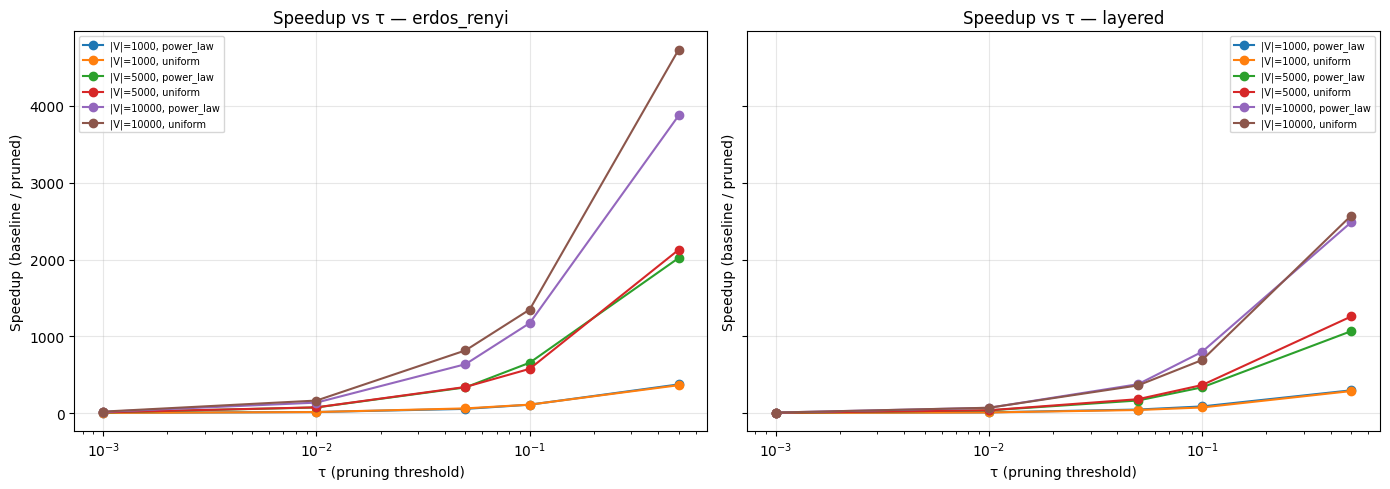

In [2]:
## ── Plot 1: Speedup vs τ ──────────────────────────────────────────────────────
# For each config (graph_type, graph_size, avg_degree, distribution, run),
# speedup = baseline_time / pruned_time

# Merge baseline timing into pruned rows
bl_time = baseline[["graph_type", "graph_size", "avg_degree", "distribution", "run",
                     "execution_time_ms"]].rename(columns={"execution_time_ms": "baseline_ms"})
merged = pruned.merge(bl_time, on=["graph_type", "graph_size", "avg_degree", "distribution", "run"])
merged["speedup"] = merged["baseline_ms"] / merged["execution_time_ms"].clip(lower=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    sub = merged[merged["graph_type"] == gtype]
    for (n, dist), grp in sub.groupby(["graph_size", "distribution"]):
        means = grp.groupby("tau")["speedup"].mean()
        label = f"|V|={n}, {dist}"
        ax.plot(means.index, means.values, marker="o", label=label)
    ax.set_xlabel("τ (pruning threshold)")
    ax.set_ylabel("Speedup (baseline / pruned)")
    ax.set_title(f"Speedup vs τ — {gtype}")
    ax.legend(fontsize=7)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "plot1_speedup_vs_tau.png", dpi=150, bbox_inches="tight")
plt.show()

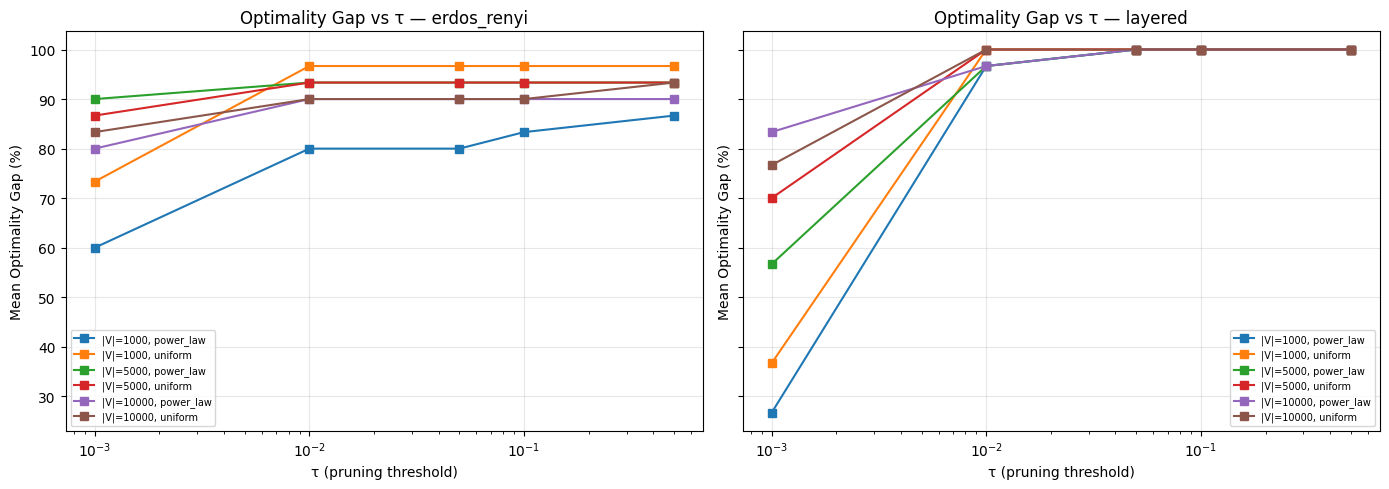

In [3]:
## ── Plot 2: Optimality Gap vs τ ───────────────────────────────────────────────
# optimality_gap_pct is already computed in experiment_results.csv
# 100 means no path found by pruned; otherwise it's the % increase in cost

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    sub = merged[merged["graph_type"] == gtype]
    for (n, dist), grp in sub.groupby(["graph_size", "distribution"]):
        means = grp.groupby("tau")["optimality_gap_pct"].mean()
        label = f"|V|={n}, {dist}"
        ax.plot(means.index, means.values, marker="s", label=label)
    ax.set_xlabel("τ (pruning threshold)")
    ax.set_ylabel("Mean Optimality Gap (%)")
    ax.set_title(f"Optimality Gap vs τ — {gtype}")
    ax.legend(fontsize=7)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "plot2_optimality_gap_vs_tau.png", dpi=150, bbox_inches="tight")
plt.show()

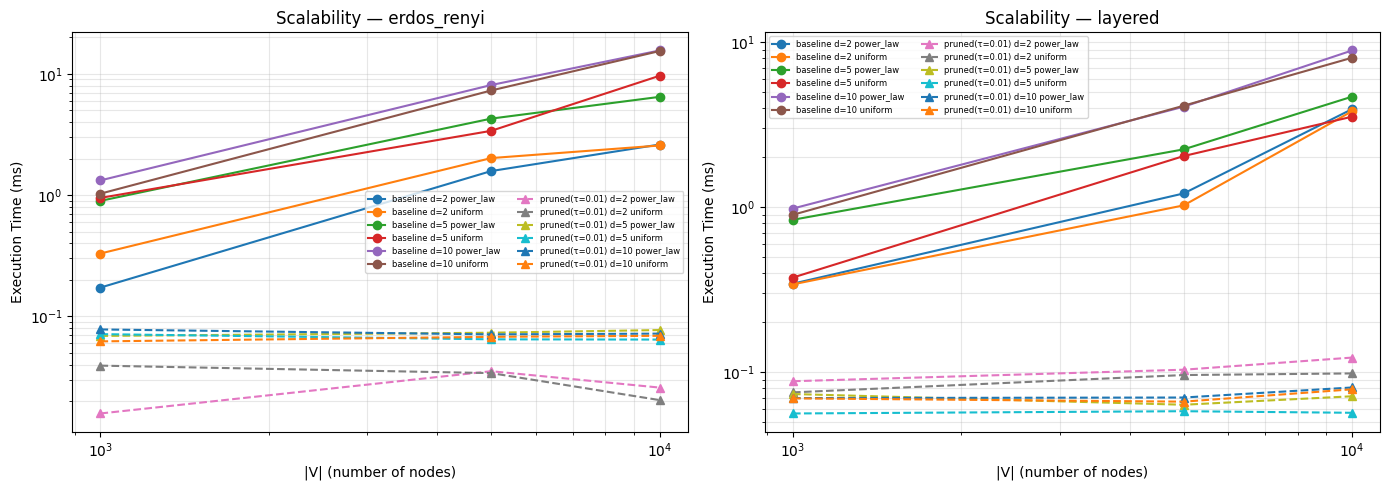

In [4]:
## ── Plot 3: Scalability — Execution Time vs |V| (log-log) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    # Baseline scalability
    bl_sub = baseline[baseline["graph_type"] == gtype]
    for (deg, dist), grp in bl_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["execution_time_ms"].mean()
        ax.plot(means.index, means.values, marker="o", linestyle="-",
                label=f"baseline d={deg} {dist}")

    # Pruned at tau=0.01
    pr_sub = pruned[(pruned["graph_type"] == gtype) & (pruned["tau"] == 0.01)]
    for (deg, dist), grp in pr_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["execution_time_ms"].mean()
        ax.plot(means.index, means.values, marker="^", linestyle="--",
                label=f"pruned(τ=0.01) d={deg} {dist}")

    ax.set_xlabel("|V| (number of nodes)")
    ax.set_ylabel("Execution Time (ms)")
    ax.set_title(f"Scalability — {gtype}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(IMG_DIR / "plot3_scalability.png", dpi=150, bbox_inches="tight")
plt.show()

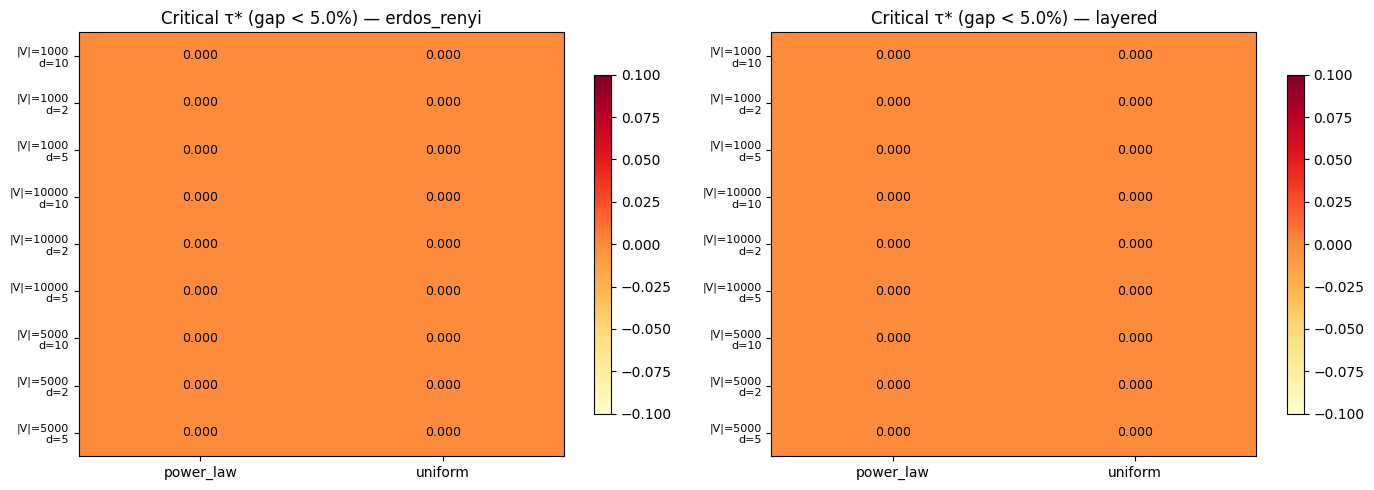

In [5]:
## ── Plot 4: Critical τ Heatmap ────────────────────────────────────────────────
# Critical τ* = largest τ where mean optimality gap < 5 % (i.e. near-optimal)
GAP_THRESHOLD = 5.0
tau_values = sorted(pruned["tau"].unique())

records = []
for (gtype, n, deg, dist), grp in pruned.groupby(
        ["graph_type", "graph_size", "avg_degree", "distribution"]):
    critical_tau = 0.0
    for tau in tau_values:
        mean_gap = grp[grp["tau"] == tau]["optimality_gap_pct"].mean()
        if mean_gap < GAP_THRESHOLD:
            critical_tau = tau
    records.append({"graph_type": gtype, "graph_size": n, "avg_degree": deg,
                     "distribution": dist, "critical_tau": critical_tau})

ct_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    sub = ct_df[ct_df["graph_type"] == gtype].copy()
    sub["config"] = sub.apply(lambda r: f"|V|={r.graph_size}\nd={r.avg_degree}", axis=1)
    pivot = sub.pivot_table(index="config", columns="distribution",
                            values="critical_tau", aggfunc="first")
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(f"Critical τ* (gap < {GAP_THRESHOLD}%) — {gtype}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(IMG_DIR / "plot4_critical_tau_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

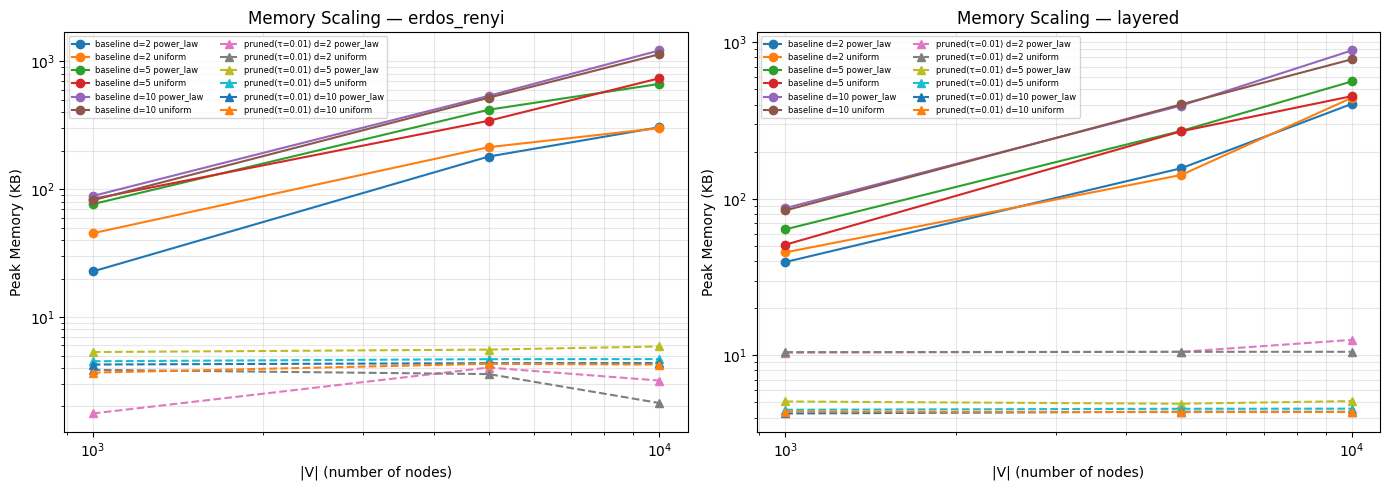

In [6]:
## ── Plot 5: Memory Scaling — Baseline vs Pruned ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    # Baseline memory
    bl_sub = baseline[baseline["graph_type"] == gtype]
    for (deg, dist), grp in bl_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["peak_memory_bytes"].mean() / 1024
        ax.plot(means.index, means.values, marker="o", linestyle="-",
                label=f"baseline d={deg} {dist}")

    # Pruned at tau=0.01
    pr_sub = pruned[(pruned["graph_type"] == gtype) & (pruned["tau"] == 0.01)]
    for (deg, dist), grp in pr_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["peak_memory_bytes"].mean() / 1024
        ax.plot(means.index, means.values, marker="^", linestyle="--",
                label=f"pruned(τ=0.01) d={deg} {dist}")

    ax.set_xlabel("|V| (number of nodes)")
    ax.set_ylabel("Peak Memory (KB)")
    ax.set_title(f"Memory Scaling — {gtype}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(IMG_DIR / "plot5_memory_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
## ── Plot 6: Statistical Significance — Wilcoxon Signed-Rank ──────────────────
# For each (graph_type, graph_size, avg_degree, distribution, tau), test whether
# pruned execution time differs significantly from baseline (paired by run).

results = []
for (gtype, n, deg, dist, tau), grp in merged.groupby(
        ["graph_type", "graph_size", "avg_degree", "distribution", "tau"]):
    bl_times = grp["baseline_ms"].values
    pr_times = grp["execution_time_ms"].values
    if len(bl_times) >= 5 and np.std(bl_times - pr_times) > 0:
        stat, pval = stats.wilcoxon(bl_times, pr_times, alternative="greater")
    else:
        stat, pval = np.nan, np.nan
    results.append({
        "graph_type": gtype, "graph_size": n, "avg_degree": deg,
        "distribution": dist, "tau": tau,
        "baseline_mean_ms": np.mean(bl_times),
        "pruned_mean_ms": np.mean(pr_times),
        "speedup": np.mean(bl_times) / max(np.mean(pr_times), 1e-9),
        "wilcoxon_stat": stat, "p_value": pval,
        "significant": pval < 0.05 if not np.isnan(pval) else False
    })

stat_df = pd.DataFrame(results)
sig_count = stat_df["significant"].sum()
total = len(stat_df)
print(f"Significant speedups: {sig_count}/{total} configs (p < 0.05)")
print(f"\nSummary by tau:")
print(stat_df.groupby("tau")[["speedup", "p_value", "significant"]].mean().round(4))
print(f"\nTop 10 fastest speedups:")
stat_df.sort_values("speedup", ascending=False).head(10)[
    ["graph_type", "graph_size", "avg_degree", "distribution", "tau",
     "speedup", "p_value", "significant"]]

Significant speedups: 180/180 configs (p < 0.05)

Summary by tau:
         speedup  p_value  significant
tau                                   
0.001     7.0540   0.0013          1.0
0.010    58.2163   0.0010          1.0
0.050   276.1420   0.0010          1.0
0.100   511.3871   0.0010          1.0
0.500  1739.5098   0.0010          1.0

Top 10 fastest speedups:


,graph_type,graph_size,avg_degree,distribution,tau,speedup,p_value,significant
89,erdos_renyi,10000,10,uniform,0.5,7453.415459,0.000977,True
84,erdos_renyi,10000,10,power_law,0.5,7221.342593,0.000977,True
79,erdos_renyi,10000,5,uniform,0.5,5541.568966,0.000977,True
179,layered,10000,10,uniform,0.5,3789.915094,0.000977,True
174,layered,10000,10,power_law,0.5,3528.503968,0.000977,True
59,erdos_renyi,5000,10,uniform,0.5,3459.464455,0.000977,True
54,erdos_renyi,5000,10,power_law,0.5,3173.647059,0.000977,True
74,erdos_renyi,10000,5,power_law,0.5,3092.019139,0.000977,True
83,erdos_renyi,10000,10,power_law,0.1,2270.465793,0.000977,True
169,layered,10000,5,uniform,0.5,2126.373494,0.000977,True


In [8]:
## ── Summary: Edges Relaxed Ratio & Path-Found Rate ──────────────────────────
# Shows pruning effectiveness: what fraction of edges does the pruned variant explore?
# Separates "no path found" from "suboptimal path found" for cleaner analysis.

summary_rows = []
for (gtype, n, deg, dist, tau), grp in merged.groupby(
        ["graph_type", "graph_size", "avg_degree", "distribution", "tau"]):
    bl_edges_baseline = baseline[
        (baseline["graph_type"] == gtype) & (baseline["graph_size"] == n) &
        (baseline["avg_degree"] == deg) & (baseline["distribution"] == dist)
    ]["edges_relaxed"].mean()

    # Use path_found column if available, else fall back to path_length > 0
    if "path_found" in grp.columns:
        path_found = grp["path_found"].mean()
        found_mask = grp["path_found"] == 1
    else:
        path_found = (grp["path_length"] > 0).mean()
        found_mask = grp["path_length"] > 0

    # Optimality gap only among runs where the pruned variant found a path
    found_rows = grp[found_mask]
    gap_when_found = found_rows["optimality_gap_pct"].mean() if len(found_rows) > 0 else float("nan")

    summary_rows.append({
        "graph_type": gtype, "graph_size": n, "avg_degree": deg,
        "distribution": dist, "tau": tau,
        "edges_ratio": grp["edges_relaxed"].mean() / max(bl_edges_baseline, 1),
        "path_found_rate": path_found,
        "gap_when_found": gap_when_found,
        "mean_gap_raw": grp["optimality_gap_pct"].mean()
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Mean by τ ===")
print(summary_df.groupby("tau")[["edges_ratio", "path_found_rate", "gap_when_found", "mean_gap_raw"]].mean().round(4))
print("\n=== Mean by graph_type and tau ===")
print(summary_df.groupby(["graph_type", "tau"])[["edges_ratio", "path_found_rate", "gap_when_found"]].mean().round(4))

=== Mean by τ ===
       edges_ratio  path_found_rate  gap_when_found  mean_gap_raw
tau                                                              
0.001       0.1448           0.3139             0.0       68.6111
0.010       0.0247           0.0556             0.0       94.4444
0.050       0.0055           0.0472             0.0       95.2778
0.100       0.0028           0.0444             0.0       95.5556
0.500       0.0004           0.0389             0.0       96.1111

=== Mean by graph_type and tau ===
                   edges_ratio  path_found_rate  gap_when_found
graph_type  tau                                                
erdos_renyi 0.001       0.0821           0.2111             0.0
            0.010       0.0142           0.0944             0.0
            0.050       0.0040           0.0944             0.0
            0.100       0.0024           0.0889             0.0
            0.500       0.0004           0.0778             0.0
layered     0.001       0.2075      